In [1]:
import pandas as pd
from glob import glob
from tqdm.notebook import tqdm
from datetime import datetime, timedelta
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [2]:
def get_data(dataset='windy'):
    if dataset=='windy':
        label = pd.read_csv('data/dataset/dataset/1_windy_power_2024-01-01_2024-12-31.csv')
        data  = pd.read_csv('data/dataset/dataset/1_windy_weather_1_2024-01-01_2025-02-28.csv')
        data.columns = ['time', 'direct_radiation_1', 'wind_direction_80m_1', 'wind_speed_80m_1',
                         'temperature_2m_1', 'relative_humidity_2m_1', 'precipitation_1']
        
        tmp = pd.read_csv('data/dataset/dataset/1_windy_weather_2_2024-01-01_2025-02-28.csv')
        tmp.columns = ['time', 'direct_radiation_2', 'wind_direction_80m_2', 'wind_speed_80m_2',
                         'temperature_2m_2', 'relative_humidity_2m_2', 'precipitation_2']
        data = data.merge(tmp, on='time', how='left')
        
        tmp = pd.read_csv('data/dataset/dataset/1_windy_weather_3_2024-01-01_2025-02-28.csv')
        tmp.columns = ['time', 'direct_radiation_3', 'wind_direction_80m_3', 'wind_speed_80m_3',
                         'temperature_2m_3', 'relative_humidity_2m_3', 'precipitation_3']
        data = data.merge(tmp, on='time', how='left')
        data = data.merge(label, on='time', how='left')
    else:
        
        label = pd.read_csv('data/dataset/dataset/2_sunny_power_2024-01-01_2024-12-31.csv')
        data  = pd.read_csv('data/dataset/dataset/2_sunny_weather_1_2024-01-01_2025-02-28.csv')
        data.columns = ['time', 'direct_radiation_1', 'wind_direction_80m_1', 'wind_speed_80m_1',
                         'temperature_2m_1', 'relative_humidity_2m_1', 'precipitation_1']
        
        tmp = pd.read_csv('data/dataset/dataset/2_sunny_weather_2_2024-01-01_2025-02-28.csv')
        tmp.columns = ['time', 'direct_radiation_2', 'wind_direction_80m_2', 'wind_speed_80m_2',
                         'temperature_2m_2', 'relative_humidity_2m_2', 'precipitation_2']
        data = data.merge(tmp, on='time', how='left')
        
        tmp = pd.read_csv('data/dataset/dataset/2_sunny_weather_3_2024-01-01_2025-02-28.csv')
        tmp.columns = ['time', 'direct_radiation_3', 'wind_direction_80m_3', 'wind_speed_80m_3',
                         'temperature_2m_3', 'relative_humidity_2m_3', 'precipitation_3']
        data = data.merge(tmp, on='time', how='left')
        data = data.merge(label, on='time', how='left')
    
    return data

In [3]:
data_windy = get_data(dataset='windy')
data_sunny = get_data(dataset='sunny')

In [6]:
def get_feats(data=None):
    # 特征工程
    data['time']  = pd.to_datetime(data['time'])
    
    data['month'] = data['time'].dt.month
    
    # 年周期（sin/cos）
    doy = data['time'].dt.dayofyear
    data['doy_sin'] = np.sin(2 * np.pi * (doy - 1) / 365.0)
    data['doy_cos'] = np.cos(2 * np.pi * (doy - 1) / 365.0)

    
    data['hour']  = data['time'].dt.hour + data['time'].dt.minute/60
    data['cos_hour'] = data['hour'].apply(lambda x:np.cos(2 * np.pi * x / 24))
    data['sin_hour'] = data['hour'].apply(lambda x:np.sin(2 * np.pi * x / 24))
    
    ff = ['direct_radiation_1', 'wind_direction_80m_1', 'wind_speed_80m_1', 'temperature_2m_1', 'relative_humidity_2m_1','precipitation_1', 
          'direct_radiation_2', 'wind_direction_80m_2', 'wind_speed_80m_2', 'temperature_2m_2', 'relative_humidity_2m_2','precipitation_2', 
          'direct_radiation_3', 'wind_direction_80m_3', 'wind_speed_80m_3', 'temperature_2m_3', 'relative_humidity_2m_3', 'precipitation_3'     
          ]
    for f in tqdm(ff):
        for win in [2,4,6,9,12,15,18]:
            data[f'{f}_rolling{win}_sum']  = data[f].rolling(win, center=True, min_periods=1).sum().values
            
            data[f'{f}_rolling{win}_mean'] = data[f].rolling(win, center=True, min_periods=1).mean().values
            data[f'{f}_rolling{win}_std'] = data[f].rolling(win, center=True, min_periods=1).std().values
            
            data[f'{f}_rolling{win}_max']  = data[f].rolling(win, center=True, min_periods=1).max().values
            data[f'{f}_rolling{win}_min']  = data[f].rolling(win, center=True, min_periods=1).min().values
            data[f'{f}_shift{win}']        = data[f].shift(win).values
            data[f'{f}_shift-{win}'] = data[f].shift(-win).values
            data[f'{f}_diff{win}']         = data[f].diff(win).values
            
    # 第二风向
    data['wind_dir_rad_1'] = np.deg2rad(data['wind_direction_80m_1'])
    data['wind_dir_sin_1'] = np.sin(data['wind_dir_rad_1'])
    data['wind_dir_cos_1'] = np.cos(data['wind_dir_rad_1'])
    
    data['wind_dir_rad_2'] = np.deg2rad(data['wind_direction_80m_2'])
    data['wind_dir_sin_2'] = np.sin(data['wind_dir_rad_2'])
    data['wind_dir_cos_2'] = np.cos(data['wind_dir_rad_2'])
    
    data['wind_dir_rad_3'] = np.deg2rad(data['wind_direction_80m_3'])
    data['wind_dir_sin_3'] = np.sin(data['wind_dir_rad_3'])
    data['wind_dir_cos_3'] = np.cos(data['wind_dir_rad_3'])
    
    # 
    # U = wind_speed * np.sin(wind_direction * np.pi / 180)
    # V = wind_speed * np.cos(wind_direction * np.pi / 180)
    data['u1'] = data['wind_speed_80m_1'] * np.sin(data['wind_direction_80m_1'] * np.pi / 180)
    data['u2'] = data['wind_speed_80m_2'] * np.sin(data['wind_direction_80m_2'] * np.pi / 180)
    data['u3'] = data['wind_speed_80m_3'] * np.sin(data['wind_direction_80m_3'] * np.pi / 180)
    
    data['v1'] = data['wind_speed_80m_1'] * np.cos(data['wind_direction_80m_1'] * np.pi / 180)
    data['v2'] = data['wind_speed_80m_2'] * np.cos(data['wind_direction_80m_2'] * np.pi / 180)
    data['v3'] = data['wind_speed_80m_3'] * np.cos(data['wind_direction_80m_3'] * np.pi / 180)
    
    return data

In [ ]:
data_windy = get_feats(data_windy)
data_sunny = get_feats(data_sunny)

In [ ]:
def train_model(train_data, val_data, test_data, params, target_col, model_type='lgb'):
    feature_cols = [col for col in train_data.columns if col != target_col]
    trn_x = train_data[feature_cols]
    trn_y = train_data[target_col]
    val_x = val_data[feature_cols]
    val_y = val_data[target_col]
    importance = 0
    
    if model_type == 'lgb':
        # LightGBM
        train_matrix = lgb.Dataset(trn_x, label=trn_y)
        valid_matrix = lgb.Dataset(val_x, label=val_y)
        model = lgb.train(
            params=params,
            train_set=train_matrix,
            valid_sets=[train_matrix, valid_matrix],
            valid_names=('train', 'val'),
            num_boost_round=2000,
            callbacks=[
                lgb.early_stopping(50, first_metric_only=True),
                lgb.log_evaluation(100),
            ],
        )
        best_iteration = model.best_iteration
        importance = model.feature_importance(importance_type='gain')
    elif model_type == 'xgb':
        # XGBoost
        dtrain = xgb.DMatrix(trn_x, label=trn_y)
        dvalid = xgb.DMatrix(val_x, label=val_y)
        evals_result = {}
        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=2000,
            evals=[(dtrain, 'train'), (dvalid, 'val')],
            early_stopping_rounds=50,
            evals_result=evals_result,
            verbose_eval=100
        )
        best_iteration = model.best_iteration
    elif model_type == 'cat':
        # CatBoost
        train_pool = cb.Pool(trn_x, label=trn_y)
        valid_pool = cb.Pool(val_x, label=val_y)
        model = cb.CatBoostRegressor(
            **params,
            iterations=2000,
            early_stopping_rounds=50,
            #verbose=100
        )
        model.fit(train_pool, eval_set=valid_pool)
        best_iteration = model.best_iteration_
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    print(f"Best iteration found: {best_iteration}")

    if model_type == 'xgb':
        val_pred = model.predict(xgb.DMatrix(val_x))#, ntree_limit=best_iteration
    else:
        val_pred = model.predict(val_x)#, ntree_limit=best_iteration
    val_rmse = mean_squared_error(val_y, val_pred)
    print(f"Validation RMSE: {val_rmse:.5f}")
    

    full_train_data = pd.concat([train_data, val_data], axis=0)
    full_trn_x = full_train_data[feature_cols]
    full_trn_y = full_train_data[target_col]

    print("Step 2: Training with All data using the best iteration...")
    if model_type == 'lgb':
        full_train_matrix = lgb.Dataset(full_trn_x, label=full_trn_y)
        best_model = lgb.train(
            params=params,
            train_set=full_train_matrix,
            valid_sets=[full_train_matrix],
            valid_names=('train',),
            num_boost_round=best_iteration+int(best_iteration*0.1),
            callbacks=[lgb.log_evaluation(100)],
        )
    elif model_type == 'xgb':
        full_dtrain = xgb.DMatrix(full_trn_x, label=full_trn_y)
        best_model = xgb.train(
            params=params,
            dtrain=full_dtrain,
            num_boost_round=best_iteration,
            verbose_eval=100
        )
    elif model_type == 'cat':
        full_train_pool = cb.Pool(full_trn_x, label=full_trn_y)
        best_model = cb.CatBoostRegressor(
            **params,
            iterations=best_iteration,
            #verbose=100
        )
        best_model.fit(full_train_pool)

        

    test_x = test_data[feature_cols]
    if model_type == 'xgb':
        predictions = best_model.predict(xgb.DMatrix(test_x))
    else:
        predictions = best_model.predict(test_x)

    return best_model, val_pred, predictions,importance


lgb_params = {
    'learning_rate': 0.02,
    'boosting_type': 'gbdt',
    'objective': 'rmse', #rmse  mae
    'metric': 'rmse',
    'num_leaves': 67,
    'verbose': -1,
    'seed': 2222,
    'n_jobs': 4,
    'min_child_weight': 9,
    'max_depth': 6,
    'lambda_l1': 0.8,
    'lambda_l2': 1.5,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.95,
    'bagging_freq': 5,
}

xgb_params = {
    'learning_rate': 0.05,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'max_depth': 6,
    #'min_child_weight': 9,
    'lambda': 0.85,
    'alpha': 0.85,
    'seed': 2222,
    'n_jobs': 4,
}

cat_params = {
    'learning_rate': 0.05,
    'grow_policy':'Lossguide',
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'depth': 6,
    'l2_leaf_reg': 0.8,  #0.8
    'random_seed': 2222,
    'thread_count': 4,
    'rsm': 0.5,               # 特征采样比例，类似 LightGBM 的 feature_fraction
    'subsample': 0.95,        # 数据采样比例，类似 LightGBM 的 bagging_fraction
    'bootstrap_type': 'MVS',  # 数据采样方法
    
    'verbose': 100,
}
# 1 2 3 4
# 5
target_col = 'real_power'
features   = [f for f in data_windy.columns if f not in ['time', 'real_power','pred','dayofyear',target_col]]
df_train = data_windy.query("time < '2024-11-01' ").copy()
df_valid = data_windy.query("time >= '2024-11-01' & time < '2025-01-01'").copy()
df_test  = data_windy.query("time >= '2025-01-01'").copy()

df_train = df_train[df_train[target_col]>=0].reset_index(drop=True).copy()

#features   = ['wind_speed_80m_1_rolling18_sum', 'wind_speed_80m_1_rolling15_sum', 'wind_speed_80m_1_rolling15_mean', 'wind_speed_80m_3_rolling18_sum', 'wind_speed_80m_1_rolling18_mean', 'wind_speed_80m_1_rolling9_min', 'doy_cos', 'wind_speed_80m_3_rolling18_mean', 'wind_speed_80m_3_rolling15_sum', 'wind_speed_80m_1_rolling12_min', 'doy_sin', 'wind_speed_80m_1_rolling12_sum', 'wind_speed_80m_1_rolling12_mean', 'wind_speed_80m_3_shift-2', 'wind_speed_80m_1_rolling6_min', 'wind_speed_80m_3_rolling15_mean', 'wind_speed_80m_2_rolling18_sum', 'month', 'wind_speed_80m_2_rolling18_mean', 'wind_speed_80m_2_rolling15_mean', 'wind_speed_80m_2_rolling18_min', 'wind_speed_80m_2_rolling9_max', 'wind_speed_80m_3_rolling18_min', 'wind_speed_80m_2_rolling2_max', 'wind_speed_80m_2_rolling15_min', 'wind_speed_80m_3_rolling9_max', 'wind_speed_80m_3_shift-4', 'wind_speed_80m_1_rolling15_min', 'wind_speed_80m_2_rolling6_max', 'wind_speed_80m_3_rolling12_min', 'temperature_2m_1_shift18', 'wind_speed_80m_2_rolling18_max', 'wind_speed_80m_2_rolling4_max', 'temperature_2m_1_diff15', 'wind_speed_80m_1_rolling18_min', 'wind_speed_80m_1_rolling12_max', 'temperature_2m_1_rolling15_min', 'wind_speed_80m_2_rolling12_min', 'wind_speed_80m_2_rolling15_sum', 'wind_speed_80m_2_shift6', 'wind_speed_80m_3_rolling12_max', 'temperature_2m_1_rolling18_min', 'wind_speed_80m_1_rolling18_max', 'temperature_2m_3_diff18', 'wind_speed_80m_1_rolling15_max', 'direct_radiation_3_rolling18_max', 'wind_speed_80m_3_rolling9_min', 'temperature_2m_3_shift-18', 'wind_speed_80m_2_rolling12_max', 'wind_speed_80m_3_rolling15_min', 'temperature_2m_1_diff12', 'wind_speed_80m_3_rolling15_max', 'wind_speed_80m_2_rolling15_max', 'temperature_2m_3_shift18', 'wind_speed_80m_3_rolling9_sum', 'wind_dir_cos_1', 'wind_speed_80m_2_rolling12_mean', 'wind_speed_80m_3_shift9', 'temperature_2m_1_shift-18', 'temperature_2m_1_shift-12', 'wind_speed_80m_3_rolling12_sum', 'temperature_2m_1_shift-15', 'temperature_2m_1_rolling12_min', 'temperature_2m_2_diff9', 'wind_speed_80m_1_rolling4_sum', 'wind_speed_80m_2_shift9', 'temperature_2m_1_rolling18_max', 'wind_speed_80m_1_rolling9_sum', 'wind_speed_80m_3_rolling6_max', 'wind_speed_80m_1_rolling9_max', 'temperature_2m_2_shift18', 'wind_speed_80m_3_rolling18_max', 'wind_speed_80m_3_shift12', 'temperature_2m_1_shift15', 'direct_radiation_3_rolling15_max', 'wind_speed_80m_2_rolling2_sum', 'temperature_2m_3_diff15', 'temperature_2m_2_diff12', 'wind_dir_cos_3', 'wind_speed_80m_3', 'wind_speed_80m_1_shift15', 'wind_speed_80m_2_rolling12_sum', 'temperature_2m_2_rolling18_max', 'wind_speed_80m_3_rolling9_mean', 'temperature_2m_3_shift-15', 'wind_speed_80m_2_diff18', 'wind_direction_80m_1_diff9', 'temperature_2m_1_shift6', 'hour', 'relative_humidity_2m_3_shift-9', 'wind_speed_80m_1_rolling6_max', 'temperature_2m_2_shift-9', 'temperature_2m_3_rolling18_max', 'wind_speed_80m_1_rolling4_max', 'wind_direction_80m_2_shift9', 'wind_speed_80m_1_rolling4_min', 'relative_humidity_2m_1_shift-12', 'wind_direction_80m_2_shift15', 'wind_speed_80m_3_shift15', 'temperature_2m_2_shift12']
features = ['wind_speed_80m_1_rolling18_sum', 'wind_speed_80m_1_rolling18_mean', 'wind_speed_80m_1_rolling15_mean', 'wind_speed_80m_1_rolling15_sum', 'wind_speed_80m_3_rolling18_sum', 'wind_speed_80m_1_rolling9_min', 'wind_speed_80m_3_rolling18_mean', 'doy_cos', 'wind_speed_80m_1_rolling12_mean', 'wind_speed_80m_1_rolling12_min', 'wind_speed_80m_3_shift-2', 'doy_sin', 'wind_speed_80m_1_rolling9_sum', 'wind_speed_80m_3_rolling15_sum', 'wind_speed_80m_1_rolling12_sum', 'wind_speed_80m_1_rolling6_min', 'wind_speed_80m_2_rolling18_mean', 'month', 'wind_speed_80m_3_rolling9_max', 'wind_speed_80m_3_rolling15_mean', 'wind_speed_80m_3_rolling18_min', 'wind_speed_80m_3_rolling12_min', 'wind_speed_80m_2_rolling18_min', 'wind_speed_80m_2_rolling4_max', 'wind_speed_80m_2_rolling15_sum', 'wind_speed_80m_2_rolling15_min', 'wind_speed_80m_2_rolling15_mean', 'wind_speed_80m_2_rolling18_sum', 'wind_speed_80m_3_shift-4', 'temperature_2m_1_rolling15_min', 'wind_speed_80m_1_rolling12_max', 'wind_speed_80m_2_rolling9_max', 'wind_speed_80m_2_rolling18_max', 'temperature_2m_1_diff15', 'wind_speed_80m_1_rolling18_max', 'wind_speed_80m_2_rolling15_max', 'wind_speed_80m_2_shift6', 'temperature_2m_3_diff18', 'wind_speed_80m_1_rolling18_min', 'temperature_2m_1_shift18', 'wind_speed_80m_1_rolling15_max', 'direct_radiation_3_rolling18_max', 'wind_speed_80m_3_rolling12_max', 'wind_speed_80m_2_rolling2_max', 'wind_speed_80m_3_rolling18_max', 'wind_speed_80m_2_rolling6_max', 'wind_speed_80m_3_rolling15_min', 'v2', 'wind_speed_80m_1_rolling15_min', 'wind_speed_80m_2_rolling9_min', 'wind_speed_80m_2_rolling12_min', 'temperature_2m_1_shift-18', 'v3', 'temperature_2m_3_shift-18', 'temperature_2m_1_rolling18_min', 'temperature_2m_1_diff12', 'temperature_2m_1_shift15', 'temperature_2m_1_rolling12_min', 'wind_speed_80m_3_rolling6_max', 'wind_speed_80m_3_rolling15_max', 'wind_speed_80m_2_rolling12_max', 'wind_speed_80m_3_rolling12_sum', 'temperature_2m_3_shift18', 'temperature_2m_2_diff9', 'temperature_2m_1_shift-12', 'wind_speed_80m_2_rolling12_sum', 'wind_speed_80m_1_rolling9_max', 'wind_speed_80m_1_rolling4_max', 'wind_speed_80m_3_rolling9_mean', 'wind_speed_80m_3', 'wind_speed_80m_2_shift9', 'wind_speed_80m_1_rolling4_min', 'wind_speed_80m_1_rolling6_max', 'wind_speed_80m_2_shift4', 'temperature_2m_3_shift-15', 'temperature_2m_3_shift15', 'wind_speed_80m_3_shift9', 'wind_speed_80m_2_diff18', 'temperature_2m_2_shift12', 'wind_speed_80m_3_shift12', 'temperature_2m_1_shift-15', 'temperature_2m_1_rolling18_max', 'temperature_2m_2_rolling18_min', 'temperature_2m_3_diff4', 'temperature_2m_2_shift-12', 'wind_speed_80m_2_rolling2_mean', 'u1', 'direct_radiation_3_rolling15_max', 'temperature_2m_2_diff4', 'temperature_2m_2_shift18', 'relative_humidity_2m_1_shift-9', 'v1', 'relative_humidity_2m_3_rolling18_min', 'wind_speed_80m_2_rolling12_mean', 'wind_speed_80m_3_rolling9_sum', 'temperature_2m_1_shift6', 'wind_speed_80m_2_shift-18', 'u2', 'wind_speed_80m_2_shift12', 'temperature_2m_3_shift-12']


print(len(features))
# target_col = 'real_power'
# features   = [f for f in data_sunny.columns if f not in ['time', 'real_power','pred','dayofyear']]
# print(len(features))
# df_train = data_sunny.query("time < '2024-11-01' ").copy()
# df_valid = data_sunny.query("time >= '2024-11-01' & time < '2025-01-01'").copy()
# df_test  = data_sunny.query("time >= '2025-01-01'").copy()
# df_train[target_col] = df_train[target_col].ffill()
# df_valid[target_col] = df_valid[target_col].ffill()


for model_type in ['lgb']:#'lgb','xgb',,'xgb','cat','xgb','cat'
    print(f"Training {model_type.upper()} model...")
    if model_type == 'lgb':
        # 训练风电
        best_model, val_lgb_1, predictions_lgb_1, importance = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            lgb_params, target_col, model_type=model_type
        )
       
    elif model_type == 'xgb':
        best_model, val_xgb, predictions_xgb, _ = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            xgb_params, target_col, model_type=model_type
        )
    elif model_type == 'cat':
        best_model, val_cbt, predictions_cbt, _ = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            cat_params, target_col, model_type=model_type
        )

100
Training LGB model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 20.1118	val's rmse: 36.4517
Early stopping, best iteration is:
[130]	train's rmse: 18.2053	val's rmse: 36.3042
Evaluated only: rmse
Best iteration found: 130
Validation RMSE: 1317.99415
Step 2: Training with All data using the best iteration...
[100]	train's rmse: 21.5978


In [10]:
df_imp = pd.DataFrame()
df_imp['feature'] = features
df_imp['imp']     = importance
topK = df_imp.sort_values(by='imp',ascending=False)[:100]['feature'].tolist()
print(topK)


['wind_speed_80m_1_rolling18_sum', 'wind_speed_80m_1_rolling18_mean', 'wind_speed_80m_1_rolling15_mean', 'wind_speed_80m_1_rolling15_sum', 'wind_speed_80m_3_rolling18_sum', 'wind_speed_80m_1_rolling9_min', 'wind_speed_80m_3_rolling18_mean', 'doy_cos', 'wind_speed_80m_1_rolling12_mean', 'wind_speed_80m_1_rolling12_min', 'wind_speed_80m_3_shift-2', 'doy_sin', 'wind_speed_80m_1_rolling9_sum', 'wind_speed_80m_3_rolling15_sum', 'wind_speed_80m_1_rolling12_sum', 'wind_speed_80m_1_rolling6_min', 'wind_speed_80m_2_rolling18_mean', 'month', 'wind_speed_80m_3_rolling9_max', 'wind_speed_80m_3_rolling15_mean', 'wind_speed_80m_3_rolling18_min', 'wind_speed_80m_3_rolling12_min', 'wind_speed_80m_2_rolling18_min', 'wind_speed_80m_2_rolling4_max', 'wind_speed_80m_2_rolling15_sum', 'wind_speed_80m_2_rolling15_min', 'wind_speed_80m_2_rolling15_mean', 'wind_speed_80m_2_rolling18_sum', 'wind_speed_80m_3_shift-4', 'temperature_2m_1_rolling15_min', 'wind_speed_80m_1_rolling12_max', 'wind_speed_80m_2_rolling9

<Axes: >

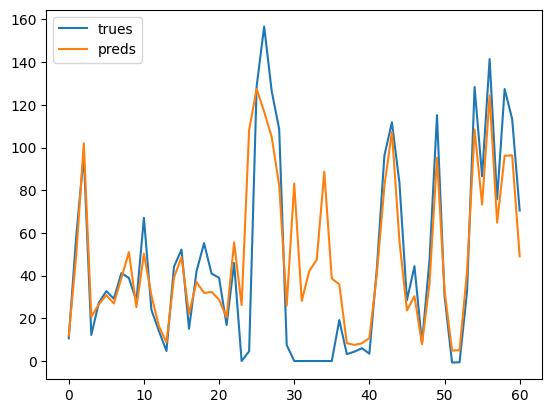

In [7]:
df_true_predict = pd.DataFrame({
    "dayofyear": df_valid['time'].dt.dayofyear,
    "preds": val_lgb_1,
    "trues": df_valid['real_power'].values,
})
grouped = df_true_predict.groupby("dayofyear")
daily_mean = grouped[['trues', 'preds']].mean().reset_index()
daily_mean[['trues', 'preds']].plot()


In [8]:

best_w, best_score,best_alpha  = None, -1, None
for alpha in range(85,101):
    alpha = alpha / 100
    for w in range(1, 50):
        def get_score(df):
            preds = df['preds'] * alpha
            preds = preds.rolling(w, center=True, min_periods=1).mean()
            trues = df['trues'].values
            mask = trues > 10
            if mask.sum() == 0:
                return 0
            squared_errors = ((trues[mask] - preds[mask]) / trues[mask]) ** 2
            CR = 1 - np.sqrt(np.mean(squared_errors))
            return max(0, CR)

        score = df_true_predict.groupby('dayofyear')[['preds','trues']].apply(get_score).mean()
        if score > best_score:
            best_score, best_w, best_alpha = score, w, alpha
print(best_score, best_w, best_alpha)

0.44843072572579334 11 0.85


<Axes: >

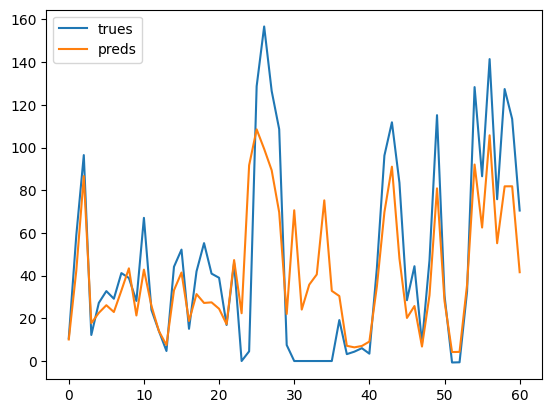

In [9]:
df_true_predict = pd.DataFrame({
    "dayofyear": df_valid['time'].dt.dayofyear,
    "preds": val_lgb_1,
    "trues": df_valid['real_power'].values,
})
df_true_predict['preds'] =(df_true_predict['preds'] * 0.85).rolling(11, center=True, min_periods=1).mean()
grouped = df_true_predict.groupby("dayofyear")
daily_mean = grouped[['trues', 'preds']].mean().reset_index()
daily_mean[['trues', 'preds']].plot()

In [ ]:
def train_model(train_data, val_data, test_data, params, target_col, model_type='lgb'):

    feature_cols = [col for col in train_data.columns if col != target_col]
    
    trn_x = train_data[feature_cols]
    trn_y = train_data[target_col]
    val_x = val_data[feature_cols]
    val_y = val_data[target_col]
    importance = 0
    
    if model_type == 'lgb':
        # LightGBM
        train_matrix = lgb.Dataset(trn_x, label=trn_y)
        valid_matrix = lgb.Dataset(val_x, label=val_y)
        model = lgb.train(
            params=params,
            train_set=train_matrix,
            valid_sets=[train_matrix, valid_matrix],
            valid_names=('train', 'val'),
            num_boost_round=2000,
            callbacks=[
                lgb.early_stopping(50, first_metric_only=True),
                lgb.log_evaluation(100),
            ],
        )
        best_iteration = model.best_iteration
        importance = model.feature_importance(importance_type='gain')
    elif model_type == 'xgb':
        # XGBoost
        dtrain = xgb.DMatrix(trn_x, label=trn_y)
        dvalid = xgb.DMatrix(val_x, label=val_y)
        evals_result = {}
        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=2000,
            evals=[(dtrain, 'train'), (dvalid, 'val')],
            early_stopping_rounds=50,
            evals_result=evals_result,
            verbose_eval=100
        )
        best_iteration = model.best_iteration
    elif model_type == 'cat':
        # CatBoost
        train_pool = cb.Pool(trn_x, label=trn_y)
        valid_pool = cb.Pool(val_x, label=val_y)
        model = cb.CatBoostRegressor(
            **params,
            iterations=2000,
            early_stopping_rounds=50,
            #verbose=100
        )
        model.fit(train_pool, eval_set=valid_pool)
        best_iteration = model.best_iteration_
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    print(f"Best iteration found: {best_iteration}")

    if model_type == 'xgb':
        val_pred = model.predict(xgb.DMatrix(val_x))#, ntree_limit=best_iteration
    else:
        val_pred = model.predict(val_x)#, ntree_limit=best_iteration
    val_rmse = mean_squared_error(val_y, val_pred)
    print(f"Validation RMSE: {val_rmse:.5f}")


    full_train_data = pd.concat([train_data, val_data], axis=0)
    full_trn_x = full_train_data[feature_cols]
    full_trn_y = full_train_data[target_col]

    print("Step 2: Training with All data using the best iteration...")
    if model_type == 'lgb':
        full_train_matrix = lgb.Dataset(full_trn_x, label=full_trn_y)
        best_model = lgb.train(
            params=params,
            train_set=full_train_matrix,
            valid_sets=[full_train_matrix],
            valid_names=('train',),
            num_boost_round=best_iteration+int(best_iteration*0.1),
            callbacks=[lgb.log_evaluation(100)],
        )
    elif model_type == 'xgb':
        full_dtrain = xgb.DMatrix(full_trn_x, label=full_trn_y)
        best_model = xgb.train(
            params=params,
            dtrain=full_dtrain,
            num_boost_round=best_iteration,
            verbose_eval=100
        )
    elif model_type == 'cat':
        full_train_pool = cb.Pool(full_trn_x, label=full_trn_y)
        best_model = cb.CatBoostRegressor(
            **params,
            iterations=best_iteration,
            #verbose=100
        )
        best_model.fit(full_train_pool)

        

    test_x = test_data[feature_cols]
    if model_type == 'xgb':
        predictions = best_model.predict(xgb.DMatrix(test_x))
    else:
        predictions = best_model.predict(test_x)

    return best_model, val_pred, predictions,importance


# 定义模型参数
lgb_params = {
    'learning_rate': 0.02,
    'boosting_type': 'gbdt',
    'objective': 'rmse',
    'metric': 'rmse',
    'num_leaves': 67,
    'verbose': -1,
    'seed': 2222,
    'n_jobs': 4,
    'min_child_weight': 9,
    'max_depth': 6,
    'lambda_l1': 0.8,
    'lambda_l2': 1.5,
    'feature_fraction': 0.5,
    'bagging_fraction': 0.95,
    'bagging_freq': 5,
}

xgb_params = {
    'learning_rate': 0.05,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'subsample': 0.9,
    'colsample_bytree': 0.6,
    'max_depth': 6,
    #'min_child_weight': 9,
    'lambda': 0.85,
    'alpha': 0.85,
    'seed': 2222,
    'n_jobs': 4,
}

cat_params = {
    'learning_rate': 0.05,
    'grow_policy':'Lossguide',
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'depth': 6,
    'l2_leaf_reg': 0.8,  #0.8
    'random_seed': 2222,
    'thread_count': 4,
    'rsm': 0.5,               # 特征采样比例，类似 LightGBM 的 feature_fraction
    'subsample': 0.95,        # 数据采样比例，类似 LightGBM 的 bagging_fraction
    'bootstrap_type': 'MVS',  # 数据采样方法
    
    'verbose': 100,
}

# target_col = 'real_power'
# features   = [f for f in data_windy.columns if f not in ['time', 'real_power','pred','dayofyear',target_col]]
# print(len(features))
# df_train = data_windy.query("time < '2024-11-01' ").copy()
# df_valid = data_windy.query("time >= '2024-11-01' & time < '2025-01-01'").copy()
# df_test  = data_windy.query("time >= '2025-01-01'").copy()

target_col = 'real_power'
features   = [f for f in data_sunny.columns if f not in ['time', 'real_power','pred','dayofyear']]
df_train = data_sunny.query("time < '2024-11-01' ").copy()
df_valid = data_sunny.query("time >= '2024-11-01' & time < '2025-01-01'").copy()
df_test  = data_sunny.query("time >= '2025-01-01'").copy()

df_train = df_train.query("(hour >= 11 and hour<14) or real_power>=10").copy()  #

df_train = df_train[df_train[target_col] >=0].reset_index(drop=True).copy()
df_valid[target_col] = df_valid[target_col].ffill()


# df_train = df_train[df_train[target_col]>0].reset_index(drop=True).copy()

features   = ['direct_radiation_3_rolling9_sum', 'cos_hour', 'direct_radiation_3_rolling6_mean', 'doy_cos', 'direct_radiation_3', 'direct_radiation_3_rolling4_max', 'direct_radiation_3_rolling9_mean', 'direct_radiation_3_rolling6_sum', 'direct_radiation_1_rolling15_std', 'direct_radiation_3_rolling12_max', 'direct_radiation_3_rolling4_min', 'direct_radiation_3_rolling6_max', 'doy_sin', 'direct_radiation_3_rolling15_sum', 'direct_radiation_3_rolling15_max', 'direct_radiation_3_rolling6_min', 'direct_radiation_3_rolling2_sum', 'direct_radiation_1_rolling9_std', 'direct_radiation_1_rolling12_std', 'direct_radiation_3_rolling9_max', 'direct_radiation_3_rolling15_min', 'hour', 'relative_humidity_2m_1_shift-2', 'direct_radiation_1_shift-2', 'direct_radiation_3_rolling18_max', 'direct_radiation_1_rolling18_std', 'direct_radiation_3_rolling9_min', 'month', 'direct_radiation_3_rolling2_mean', 'direct_radiation_3_rolling2_max', 'direct_radiation_2', 'direct_radiation_3_rolling15_mean', 'direct_radiation_1_rolling15_min', 'direct_radiation_3_rolling2_min', 'relative_humidity_2m_1_rolling9_max', 'relative_humidity_2m_1_rolling15_sum', 'direct_radiation_3_rolling18_min', 'wind_direction_80m_1_shift-18', 'wind_direction_80m_3_diff15', 'temperature_2m_3_shift18', 'direct_radiation_2_rolling18_max', 'direct_radiation_2_rolling15_max', 'direct_radiation_2_rolling6_max', 'sin_hour', 'temperature_2m_3_rolling9_std', 'direct_radiation_3_rolling12_sum', 'relative_humidity_2m_1_rolling15_min', 'direct_radiation_2_rolling18_std', 'relative_humidity_2m_1_rolling6_max', 'direct_radiation_1_rolling12_max', 'direct_radiation_2_rolling12_std', 'direct_radiation_2_rolling12_max', 'direct_radiation_2_rolling15_std', 'relative_humidity_2m_1_rolling18_min', 'direct_radiation_2_rolling4_max', 'direct_radiation_1_rolling9_min', 'temperature_2m_3_rolling4_std', 'direct_radiation_1_rolling9_max', 'direct_radiation_1_rolling18_max', 'relative_humidity_2m_1_shift-4', 'relative_humidity_2m_1_shift-6', 'wind_direction_80m_1_shift-15', 'temperature_2m_2_diff18', 'direct_radiation_2_rolling2_max', 'relative_humidity_2m_1_rolling15_mean', 'wind_dir_sin_1', 'relative_humidity_2m_1_shift18', 'relative_humidity_2m_1_rolling9_sum', 'direct_radiation_3_rolling15_std', 'temperature_2m_3', 'direct_radiation_1_rolling12_min', 'relative_humidity_2m_2_shift-9', 'temperature_2m_3_rolling6_std', 'direct_radiation_1', 'temperature_2m_3_rolling18_max', 'wind_direction_80m_2_shift-18', 'direct_radiation_1_rolling15_max', 'direct_radiation_2_shift-2', 'direct_radiation_3_shift-2', 'direct_radiation_2_rolling9_std', 'direct_radiation_2_rolling9_sum', 'wind_direction_80m_3_diff18', 'direct_radiation_1_shift-4', 'direct_radiation_1_rolling6_std', 'wind_speed_80m_2_shift15', 'direct_radiation_2_rolling9_max', 'wind_direction_80m_3_shift-15', 'relative_humidity_2m_1_rolling4_sum', 'direct_radiation_1_rolling18_min', 'wind_speed_80m_2_shift18', 'wind_direction_80m_1_shift-12', 'temperature_2m_2_diff12', 'wind_speed_80m_1_rolling18_std', 'direct_radiation_1_rolling4_sum', 'direct_radiation_2_rolling4_std', 'temperature_2m_1_shift-9', 'temperature_2m_3_rolling15_std', 'direct_radiation_2_rolling18_min', 'direct_radiation_1_diff18', 'wind_direction_80m_3_shift-18']




print(len(features))
for model_type in ['lgb']:#'lgb','xgb',,'xgb','cat','xgb','cat'
    print(f"Training {model_type.upper()} model...")
    if model_type == 'lgb':
        # 训练光电
        best_model, val_lgb_2, predictions_lgb_2, importance = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            lgb_params, target_col, model_type=model_type
        )
       
    elif model_type == 'xgb':
        best_model, val_xgb, predictions_xgb, _ = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            xgb_params, target_col, model_type=model_type
        )
    elif model_type == 'cat':
        best_model, val_cbt, predictions_cbt, _ = train_model(
            df_train[features + [target_col]],
            df_valid[features + [target_col]],
            df_test[features],
            cat_params, target_col, model_type=model_type
        )

100
Training LGB model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 2.86364	val's rmse: 10.3565
[200]	train's rmse: 2.18712	val's rmse: 9.6064
[300]	train's rmse: 1.98301	val's rmse: 9.40877
[400]	train's rmse: 1.81755	val's rmse: 9.2262
[500]	train's rmse: 1.67812	val's rmse: 9.14992
[600]	train's rmse: 1.55537	val's rmse: 9.11207
[700]	train's rmse: 1.46746	val's rmse: 9.0752
Early stopping, best iteration is:
[716]	train's rmse: 1.45363	val's rmse: 9.07244
Evaluated only: rmse
Best iteration found: 716
Validation RMSE: 82.30920
Step 2: Training with All data using the best iteration...
[100]	train's rmse: 3.19088
[200]	train's rmse: 2.35068
[300]	train's rmse: 2.04929
[400]	train's rmse: 1.8604
[500]	train's rmse: 1.70936
[600]	train's rmse: 1.58624
[700]	train's rmse: 1.48532


In [13]:
df_imp = pd.DataFrame()
df_imp['feature'] = features
df_imp['imp']     = importance
topK = df_imp.sort_values(by='imp',ascending=False)[:100]['feature'].tolist()
print(topK)

['direct_radiation_3_rolling9_sum', 'cos_hour', 'direct_radiation_3_rolling6_mean', 'doy_cos', 'direct_radiation_3', 'direct_radiation_3_rolling4_max', 'direct_radiation_3_rolling9_mean', 'direct_radiation_3_rolling6_sum', 'direct_radiation_1_rolling15_std', 'direct_radiation_3_rolling12_max', 'direct_radiation_3_rolling4_min', 'direct_radiation_3_rolling6_max', 'doy_sin', 'direct_radiation_3_rolling15_sum', 'direct_radiation_3_rolling15_max', 'direct_radiation_3_rolling6_min', 'direct_radiation_3_rolling2_sum', 'direct_radiation_1_rolling9_std', 'direct_radiation_1_rolling12_std', 'direct_radiation_3_rolling9_max', 'direct_radiation_3_rolling15_min', 'hour', 'relative_humidity_2m_1_shift-2', 'direct_radiation_1_shift-2', 'direct_radiation_3_rolling18_max', 'direct_radiation_1_rolling18_std', 'direct_radiation_3_rolling9_min', 'month', 'direct_radiation_3_rolling2_mean', 'direct_radiation_3_rolling2_max', 'direct_radiation_2', 'direct_radiation_3_rolling15_mean', 'direct_radiation_1_ro

<Axes: >

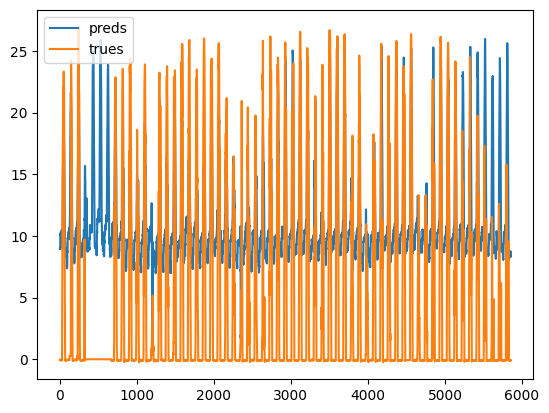

In [11]:
pd.DataFrame({
    "preds": val_lgb_2,
    "trues": df_valid['real_power'].values,
}).plot()

<Axes: >

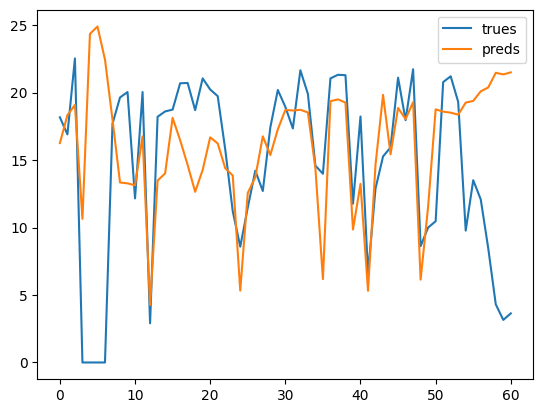

In [12]:
df_true_predict ={
    "dayofyear": [],
    "preds": [],
    "trues": [],
}
for pred, true, time in zip(val_lgb_2, df_valid['real_power'].values, df_valid['time']):
    if (11<=time.hour< 14) or true > 10:
        df_true_predict['dayofyear'].append(time.dayofyear)
        df_true_predict['preds'].append(pred)
        df_true_predict['trues'].append(true)
df_true_predict = pd.DataFrame(df_true_predict)


grouped = df_true_predict.groupby("dayofyear")
daily_mean = grouped[['trues', 'preds']].mean().reset_index()
daily_mean[['trues', 'preds']].plot()

<Axes: >

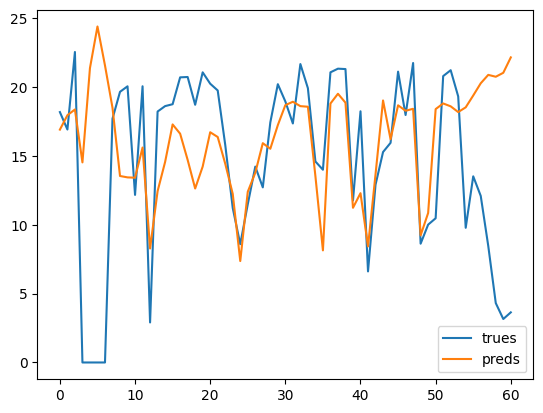

In [13]:

rolling = pd.DataFrame({
    "preds": df_true_predict['preds'].rolling(20, center=True, min_periods=1).mean(),
    "trues": df_true_predict['trues'],
    "dayofyear": df_true_predict['dayofyear'],

})
grouped = rolling.groupby("dayofyear")
daily_mean = grouped[['trues', 'preds']].mean().reset_index()
daily_mean[['trues', 'preds']].plot()

<Axes: >

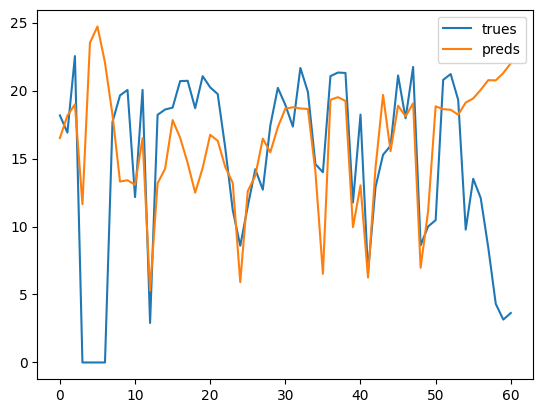

In [25]:

rolling = pd.DataFrame({
    "preds": df_true_predict['preds'].rolling(7, center=True, min_periods=1).mean(),
    "trues": df_true_predict['trues'],
    "dayofyear": df_true_predict['dayofyear'],

})
grouped = rolling.groupby("dayofyear")
daily_mean = grouped[['trues', 'preds']].mean().reset_index()
daily_mean[['trues', 'preds']].plot()

In [19]:
df_true_predict = pd.DataFrame({
    "dayofyear": df_valid['time'].dt.dayofyear,
    "hour": df_valid['time'].dt.hour,
    "preds": val_lgb_2,
    "trues": df_valid['real_power'].values,
})


best_w, best_score,best_alpha  = None, -1, None
for alpha in range(85,101):
    alpha = alpha / 100
    for w in range(1, 50):
        def get_score(df):
            preds = df['preds'] * alpha
            preds = preds.rolling(w, center=True, min_periods=1).mean()
            trues = df['trues'].values
            mask  = (trues > 10) | ((df['hour'] >= 11) & (df['hour'] < 14))

            if mask.sum() == 0:
                return 0
            squared_errors = ((trues[mask] - preds[mask]) / trues[mask]) ** 2
            CR = 1 - np.sqrt(np.mean(squared_errors))
            return max(0, CR)

        score = df_true_predict.groupby('dayofyear')[['preds','trues','hour']].apply(get_score).mean()
        if score > best_score:
            best_score, best_w, best_alpha = score, w, alpha
print(best_score, best_w, best_alpha)

0.5447709082920865 7 1.0


In [ ]:
# 这里画图，看看平滑曲线

# TODO: 这里统一更改成0.88和20，再看看结果，其他都不动

In [20]:
output1 = pd.read_csv('data/output/output1.csv')
output1['predict_power'] = predictions_lgb_1*0.88
output1['predict_power'] = output1['predict_power'].rolling(15, center=True, min_periods=1).mean()
output1.to_csv('sub/output1.csv',index=False)

In [21]:
output2 = pd.read_csv('data/output/output2.csv')
output2['predict_power'] = predictions_lgb_2*0.88
output2['predict_power'] = output2['predict_power'].rolling(15, center=True, min_periods=1).mean() 
output2.to_csv('sub/output2.csv',index=False)

0.62984